In [1]:
%load_ext autoreload
%autoreload 2

In [22]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from paths import AUDIO_DIR, METADATA_PATH#, MUSICNET_NPZ_PATH
from config import MIN_WORKS_PER_COMPOSER

from dataset import make_dataset

from evaluation import make_sample_weights, majority_vote_prediction, soft_vote_predictions, train_and_evaluate_neural_network, plot_training_history

In [5]:
metadata = pd.read_csv(METADATA_PATH)

print(metadata.head())
print(metadata.columns)

     id  composer               composition                   movement  \
0  1727  Schubert  Piano Quintet in A major                 2. Andante   
1  1728  Schubert  Piano Quintet in A major         3. Scherzo: Presto   
2  1729  Schubert  Piano Quintet in A major  4. Andantino - Allegretto   
3  1730  Schubert  Piano Quintet in A major          5. Allegro giusto   
4  1733  Schubert   Piano Sonata in A major               2. Andantino   

        ensemble            source                      transcriber  \
0  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
1  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
2  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
3  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
4     Solo Piano          Museopen                Segundo G. Yogore   

  catalog_name  seconds  
0        OP114      447  
1        OP114      251  
2        OP114      444  
3        OP114      368 

In [6]:
metadata.isna().sum()

id              0
composer        0
composition     0
movement        0
ensemble        0
source          0
transcriber     0
catalog_name    0
seconds         0
dtype: int64

In [7]:
metadata["composer"].unique()

<StringArray>
[ 'Schubert',    'Mozart',    'Dvorak',   'Cambini',     'Haydn',    'Brahms',
     'Faure',     'Ravel',      'Bach', 'Beethoven']
Length: 10, dtype: str

In [8]:
metadata["work_id"] = (
    metadata["composer"].astype(str)
    + " | "
    + metadata["composition"].astype(str)
)

# Formiranje X, y, groups

In [9]:
work_counts = (
    metadata.groupby("composer")["work_id"]
    .nunique()
)

valid_composers = work_counts[
    work_counts >= MIN_WORKS_PER_COMPOSER
].index

metadata_filtered = metadata[
    metadata["composer"].isin(valid_composers)
].copy()

print(
    metadata_filtered
    .groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


In [10]:
from midi import make_midi_dataset


X, y, groups = make_midi_dataset(
    metadata_filtered,
    AUDIO_DIR,
    use_cache=True
)

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)

Processing MIDI labels:  25%|██▍       | 74/302 [00:12<00:51,  4.42it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing MIDI labels:  25%|██▍       | 75/302 [00:12<00:46,  4.86it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing MIDI labels:  25%|██▌       | 76/302 [00:12<00:44,  5.05it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found

X: (11071, 56)
y: (11071,)
groups: (11071,)


# Isprobavanje potpuno povezanih mreza

<span style="font-size:20px">
Naime, sada cemo isprobati neke potpuno povezane mreze, zbog malog skupa podataka ne ocekujemo previse od njih, ali cemo ih svakako probati. Uglavnom cemo koristiti manje mreze jer bi se vece overfitovale na ovako malom skupu podataka, a svakako nije iskljuceno da ce se to desiti ni sa manjim arhitekturama. 

Mozemo problem posmatrati kao do sada sa podjelom kompozicija na audio segmente, i predvidjanje autora kompozicije na osnovu majority voting-a odradjenog na svim audio segmentima jedne kompozicije. Dakle, princip ostaje isti kao i kod klasicnih modela masinskog ucenja. Takodje cemo isprobati i akumuliranje feature vektora svih segmenata jedne kompozicije u jedan feature vektor za cijelu kompoziciju, sto moze potencijalno biti povoljno za neuronsku mrezu jer nece puno vidjeti isti segment iste kompozicije (sjetimo se da imamo u nasem skupu podataka vise puta istu kompoziciju samo sa razlicitim stavom). 
</span>

In [11]:
class SegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

label_encoder = LabelEncoder()

#enkodiranje klasa
y_encoded = label_encoder.fit_transform(y)

In [13]:
#Pravljenje stratified group k foldova

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    sgkf.split(
        X,
        y_encoded,
        groups
    )
)

In [18]:
folds

[(array([    0,     1,     2, ..., 11068, 11069, 11070], shape=(8916,)),
  array([  306,   307,   308, ..., 11021, 11022, 11023], shape=(2155,))),
 (array([    0,     1,     2, ..., 11068, 11069, 11070], shape=(8859,)),
  array([  447,   448,   449, ..., 10643, 10644, 10645], shape=(2212,))),
 (array([    0,     1,     2, ..., 11021, 11022, 11023], shape=(8869,)),
  array([ 1175,  1176,  1177, ..., 11068, 11069, 11070], shape=(2202,))),
 (array([  306,   307,   308, ..., 11068, 11069, 11070], shape=(8777,)),
  array([    0,     1,     2, ..., 10569, 10570, 10571], shape=(2294,))),
 (array([    0,     1,     2, ..., 11068, 11069, 11070], shape=(8863,)),
  array([  355,   356,   357, ..., 10757, 10758, 10759], shape=(2208,)))]

In [20]:
X  = X.to_numpy()


========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.8202 | val_loss=0.9099 | train_acc=0.6687 | val_acc=0.6413
Epoch 10/20 | train_loss=0.6915 | val_loss=0.8813 | train_acc=0.7255 | val_acc=0.6561
Epoch 15/20 | train_loss=0.6322 | val_loss=0.8640 | train_acc=0.7459 | val_acc=0.6733
Epoch 20/20 | train_loss=0.6000 | val_loss=0.8564 | train_acc=0.7647 | val_acc=0.6817


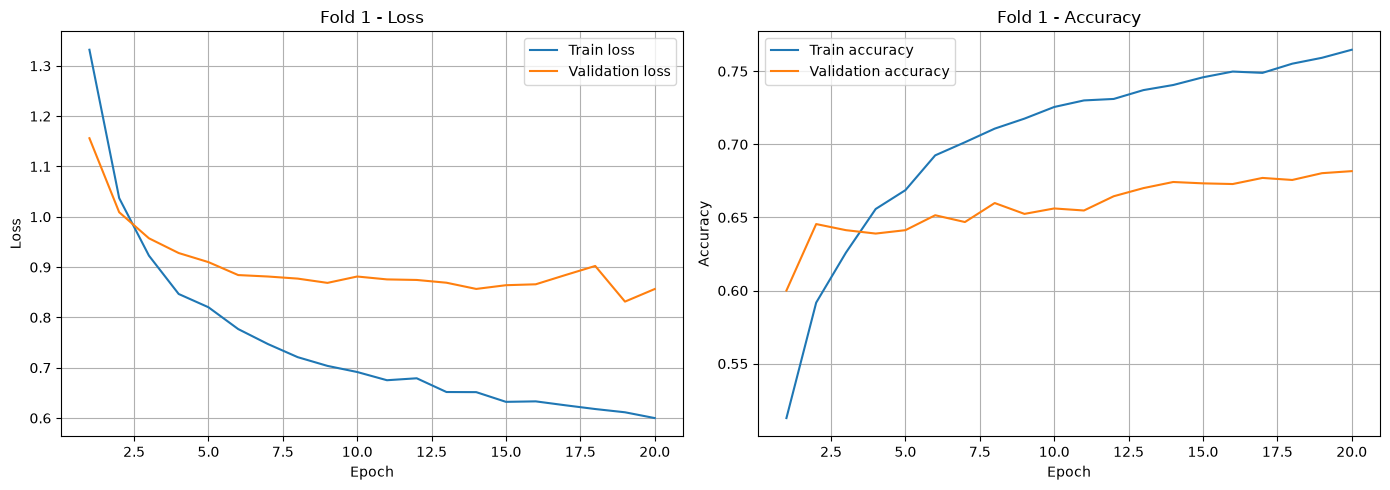

Fold 1: accuracy=0.6364, macro F1=0.3429

========== FOLD 2 ==========
Epoch 5/20 | train_loss=0.7783 | val_loss=0.9598 | train_acc=0.6939 | val_acc=0.6727
Epoch 10/20 | train_loss=0.6732 | val_loss=1.0770 | train_acc=0.7341 | val_acc=0.6930
Epoch 15/20 | train_loss=0.6229 | val_loss=1.4114 | train_acc=0.7598 | val_acc=0.6962
Epoch 20/20 | train_loss=0.5897 | val_loss=1.7512 | train_acc=0.7763 | val_acc=0.7125


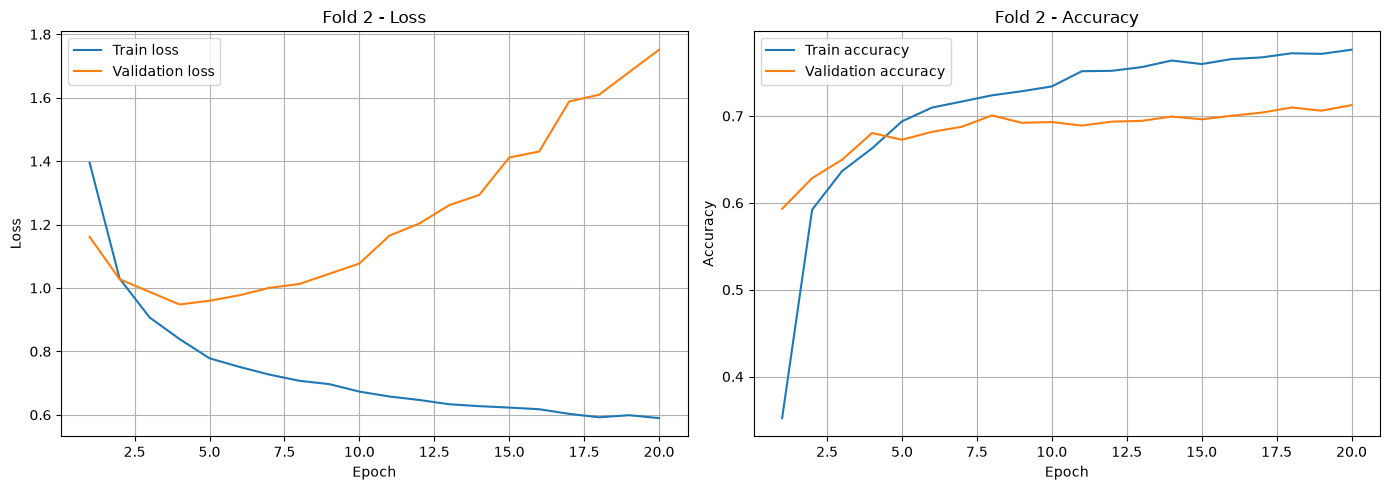

Fold 2: accuracy=0.7391, macro F1=0.4781

========== FOLD 3 ==========
Epoch 5/20 | train_loss=0.8110 | val_loss=1.5074 | train_acc=0.6868 | val_acc=0.6853
Epoch 10/20 | train_loss=0.6986 | val_loss=3.1404 | train_acc=0.7251 | val_acc=0.7139
Epoch 15/20 | train_loss=0.6430 | val_loss=5.3574 | train_acc=0.7558 | val_acc=0.7262
Epoch 20/20 | train_loss=0.6131 | val_loss=7.3799 | train_acc=0.7768 | val_acc=0.7289


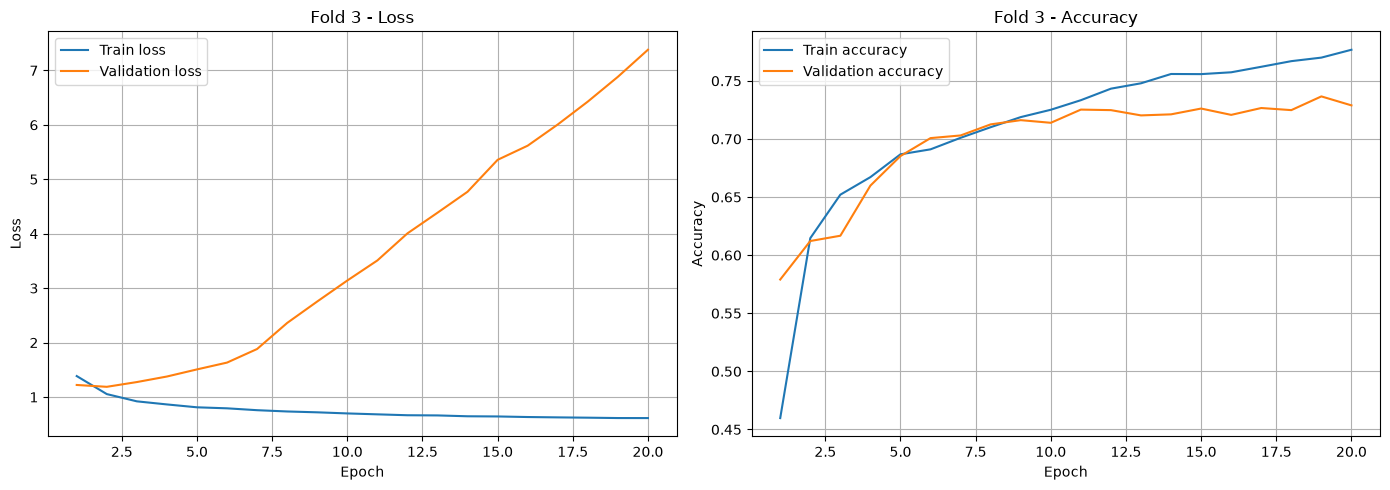

Fold 3: accuracy=0.7391, macro F1=0.4963

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.7785 | val_loss=1.2192 | train_acc=0.6960 | val_acc=0.5567
Epoch 10/20 | train_loss=0.6849 | val_loss=1.5102 | train_acc=0.7341 | val_acc=0.5628
Epoch 15/20 | train_loss=0.6434 | val_loss=1.8737 | train_acc=0.7621 | val_acc=0.5606
Epoch 20/20 | train_loss=0.6024 | val_loss=2.2327 | train_acc=0.7730 | val_acc=0.5501


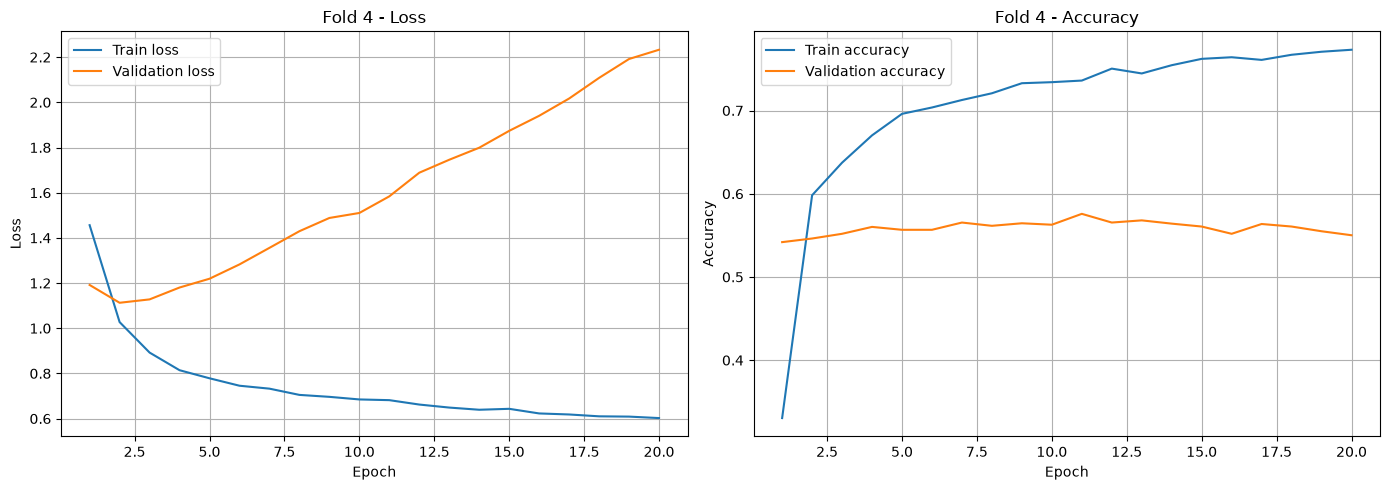

Fold 4: accuracy=0.6818, macro F1=0.4472

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.7833 | val_loss=0.9044 | train_acc=0.6754 | val_acc=0.6825
Epoch 10/20 | train_loss=0.6719 | val_loss=0.8567 | train_acc=0.7306 | val_acc=0.7188
Epoch 15/20 | train_loss=0.6297 | val_loss=0.8400 | train_acc=0.7514 | val_acc=0.7215
Epoch 20/20 | train_loss=0.5919 | val_loss=0.8427 | train_acc=0.7636 | val_acc=0.7242


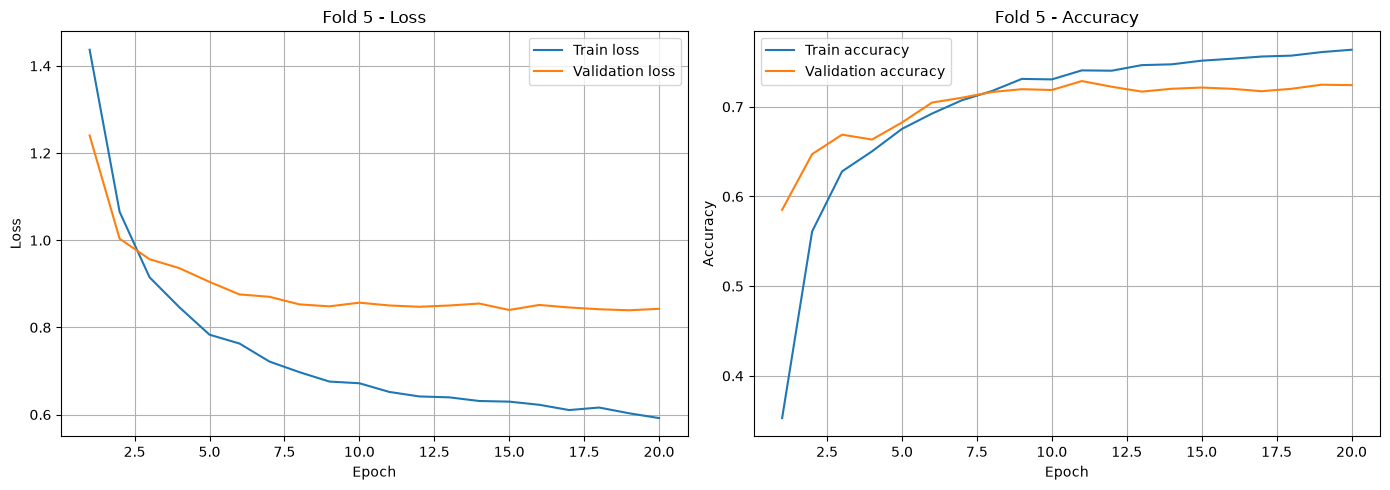

Fold 5: accuracy=0.6522, macro F1=0.5148

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6897
Mean macro F1: 0.4559


In [23]:
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001

fold_accuracies = []
fold_f1_scores = []

all_work_true = []
all_work_pred = []


for fold, (train_idx, test_idx) in enumerate(folds, start=1):

    print(f"\n========== FOLD {fold} ==========")

    # PODACI
    X_train = X[train_idx]
    y_train = y_encoded[train_idx]

    X_test = X[test_idx]
    y_test = y_encoded[test_idx]

    groups_test = groups[test_idx]


    # STANDARDIZACIJA
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # TRAIN DATASET + LOADER
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # MODEL
    model = SegmentNeuralNetwork(
        input_size=X.shape[1],
        num_classes=len(label_encoder.classes_)
    ).to(device)


    # LOSS
    criterion = nn.CrossEntropyLoss()


    # OPTIMIZER
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # =====================================================
    # OVDJE POZIVAMO FUNKCIJU ZA TRENING
    # =====================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # GRAFICI
    plot_training_history(
        history,
        fold=fold
    )


    # TEST PREDIKCIJE
    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        pred = torch.argmax(logits, dim=1).cpu().numpy()


    # MAJORITY VOTE PO DJELU
    work_true, work_pred = majority_vote_prediction(
        y_test,
        pred,
        groups_test
    )


    # METRIKE
    accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    f1 = metrics.f1_score(
        work_true,
        work_pred,
        average="macro"
    )

    fold_accuracies.append(accuracy)
    fold_f1_scores.append(f1)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    print(
        f"Fold {fold}: "
        f"accuracy={accuracy:.4f}, "
        f"macro F1={f1:.4f}"
    )


print("\n========== UKUPNI REZULTATI ==========")

print(
    f"Mean accuracy: {np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean macro F1: {np.mean(fold_f1_scores):.4f}"
)

<span style="font-size:20px">
Mozemo primijetiti znacajno preprilagodjavanje modela neuronske mreze cak i sa ovako malim brojem parametrima, mozemo probati pristup sa dodatnim smanjenjem mreze ili da uvedemo vecu regularizaciju, ili oboje. 
</span>

In [24]:
class SegmentNeuralNetworkRegularized(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.9816 | val_loss=0.9549 | train_acc=0.6197 | val_acc=0.6729
Epoch 10/20 | train_loss=0.9036 | val_loss=0.9156 | train_acc=0.6482 | val_acc=0.6742
Epoch 15/20 | train_loss=0.8708 | val_loss=0.9069 | train_acc=0.6555 | val_acc=0.6794
Epoch 20/20 | train_loss=0.8448 | val_loss=0.8713 | train_acc=0.6644 | val_acc=0.6845


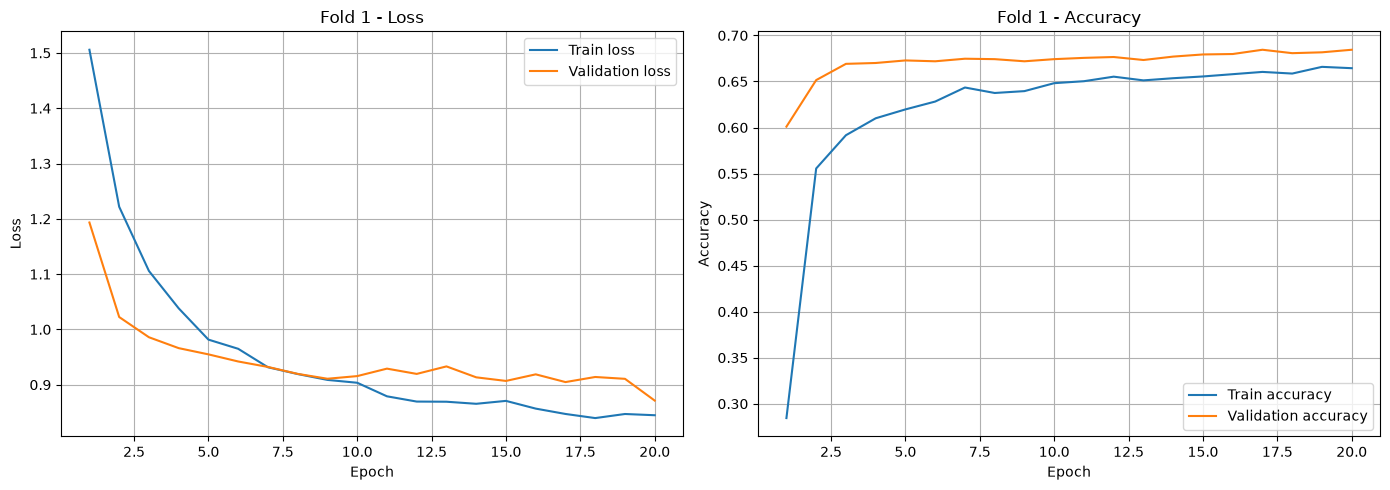

Fold 1: accuracy=0.5455, macro F1=0.2175

========== FOLD 2 ==========
Epoch 5/20 | train_loss=1.0342 | val_loss=1.1956 | train_acc=0.5928 | val_acc=0.5845
Epoch 10/20 | train_loss=0.9151 | val_loss=1.2768 | train_acc=0.6239 | val_acc=0.5931
Epoch 15/20 | train_loss=0.8650 | val_loss=1.3122 | train_acc=0.6336 | val_acc=0.6153
Epoch 20/20 | train_loss=0.8301 | val_loss=1.3819 | train_acc=0.6482 | val_acc=0.6374


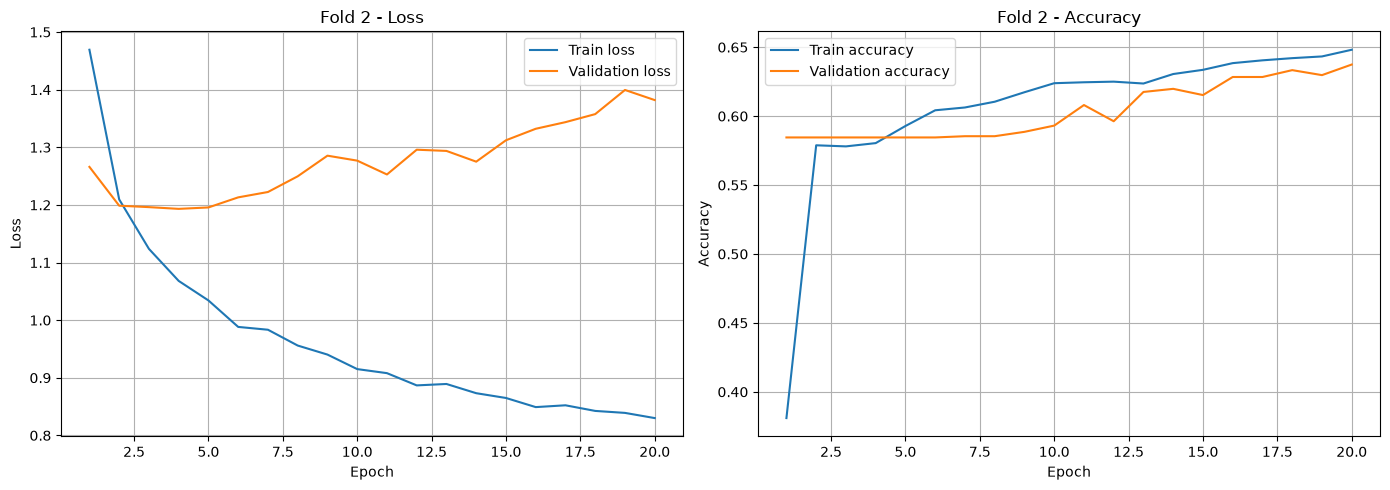

Fold 2: accuracy=0.6522, macro F1=0.3067

========== FOLD 3 ==========
Epoch 5/20 | train_loss=1.0831 | val_loss=1.0032 | train_acc=0.5889 | val_acc=0.5799
Epoch 10/20 | train_loss=0.9586 | val_loss=0.8444 | train_acc=0.6233 | val_acc=0.6512
Epoch 15/20 | train_loss=0.9144 | val_loss=0.7965 | train_acc=0.6318 | val_acc=0.6421
Epoch 20/20 | train_loss=0.8841 | val_loss=0.7293 | train_acc=0.6466 | val_acc=0.6953


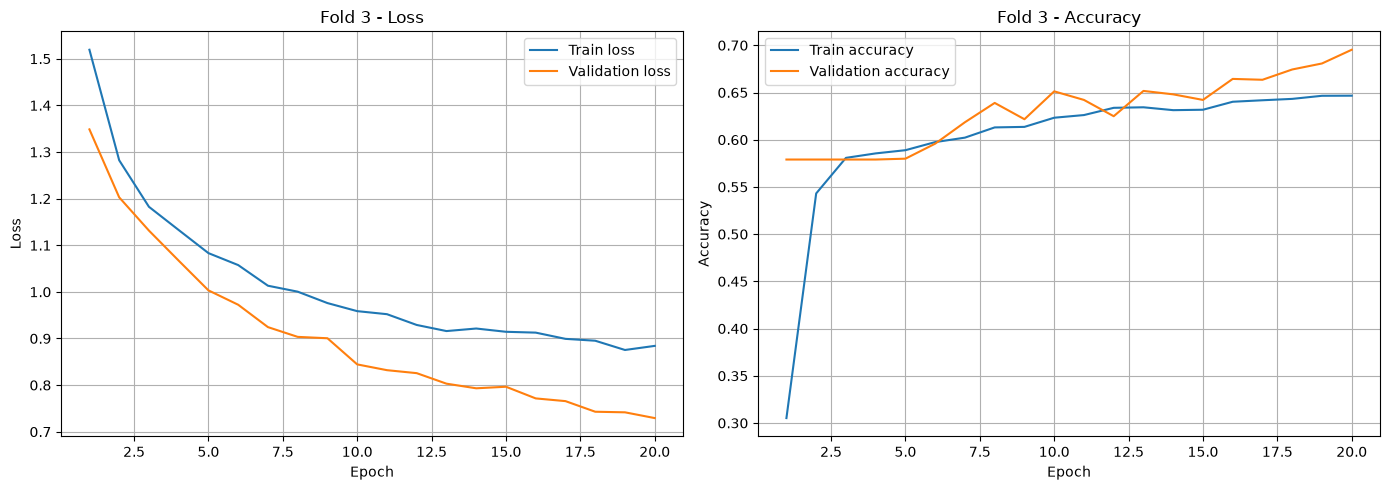

Fold 3: accuracy=0.6087, macro F1=0.2510

========== FOLD 4 ==========
Epoch 5/20 | train_loss=1.0317 | val_loss=1.1331 | train_acc=0.6136 | val_acc=0.5632
Epoch 10/20 | train_loss=0.9251 | val_loss=1.0942 | train_acc=0.6253 | val_acc=0.5654
Epoch 15/20 | train_loss=0.8900 | val_loss=1.1303 | train_acc=0.6337 | val_acc=0.5737
Epoch 20/20 | train_loss=0.8555 | val_loss=1.1148 | train_acc=0.6710 | val_acc=0.5480


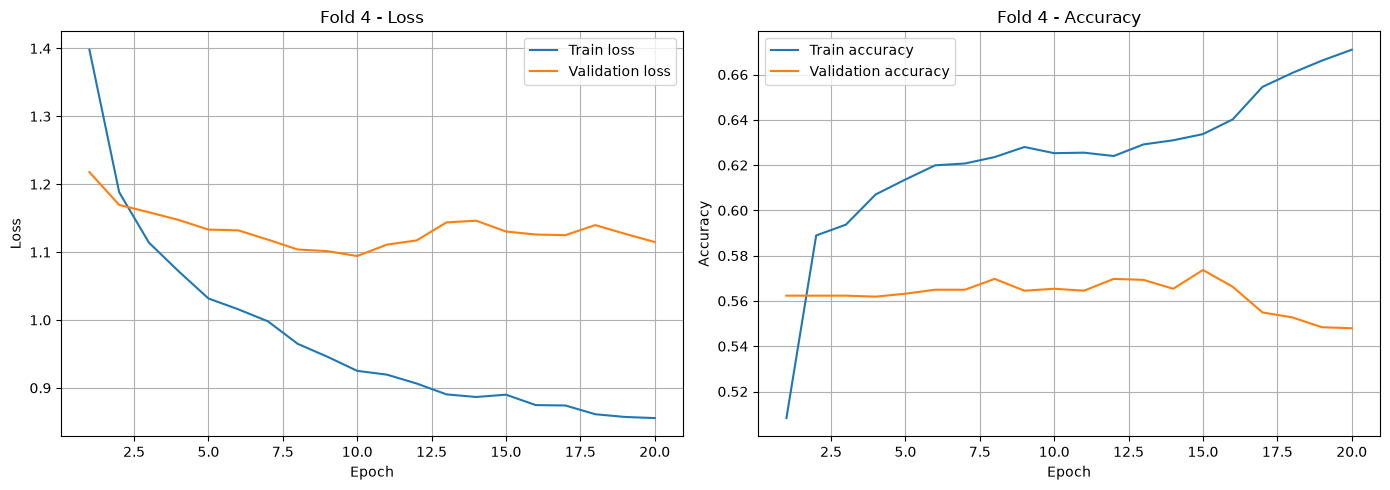

Fold 4: accuracy=0.5000, macro F1=0.1333

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.9846 | val_loss=0.9015 | train_acc=0.6175 | val_acc=0.6526
Epoch 10/20 | train_loss=0.8745 | val_loss=0.8283 | train_acc=0.6490 | val_acc=0.6952
Epoch 15/20 | train_loss=0.8409 | val_loss=0.8126 | train_acc=0.6663 | val_acc=0.7088
Epoch 20/20 | train_loss=0.8214 | val_loss=0.7855 | train_acc=0.6721 | val_acc=0.7228


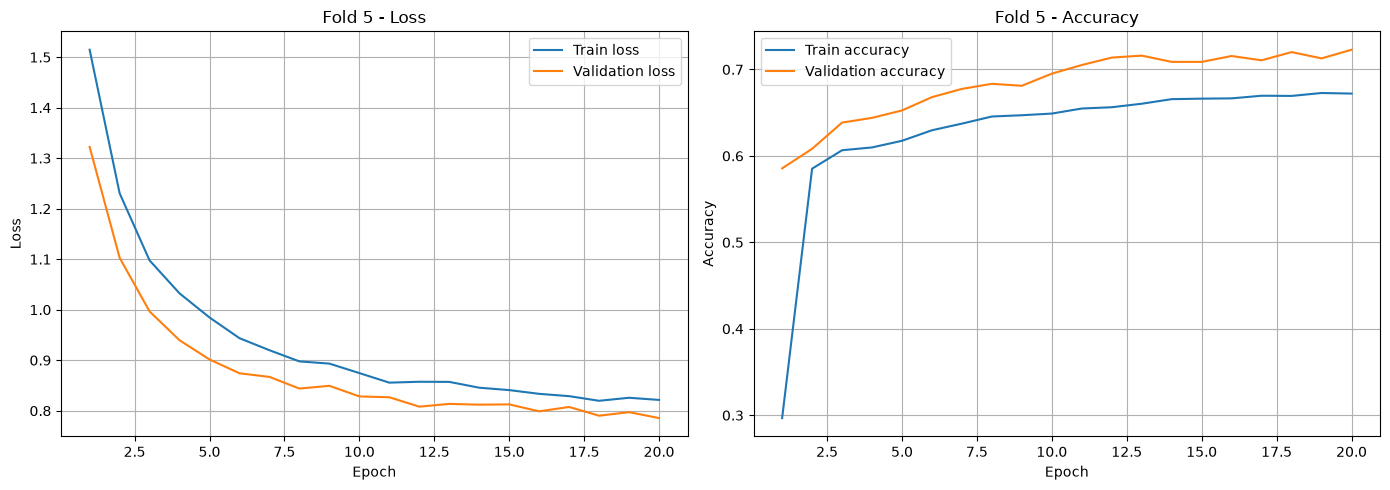

Fold 5: accuracy=0.5652, macro F1=0.3667

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.5743
Mean macro F1: 0.2550


In [25]:
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001

fold_accuracies = []
fold_f1_scores = []

all_work_true = []
all_work_pred = []


for fold, (train_idx, test_idx) in enumerate(folds, start=1):

    print(f"\n========== FOLD {fold} ==========")

    # PODACI
    X_train = X[train_idx]
    y_train = y_encoded[train_idx]

    X_test = X[test_idx]
    y_test = y_encoded[test_idx]

    groups_test = groups[test_idx]


    # STANDARDIZACIJA
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # TRAIN DATASET + LOADER
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # MODEL
    model = SegmentNeuralNetworkRegularized(
        input_size=X.shape[1],
        num_classes=len(label_encoder.classes_)
    ).to(device)


    # LOSS
    criterion = nn.CrossEntropyLoss()


    # OPTIMIZER
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # =====================================================
    # OVDJE POZIVAMO FUNKCIJU ZA TRENING
    # =====================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # GRAFICI
    plot_training_history(
        history,
        fold=fold
    )


    # TEST PREDIKCIJE
    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        pred = torch.argmax(logits, dim=1).cpu().numpy()


    # MAJORITY VOTE PO DJELU
    work_true, work_pred = majority_vote_prediction(
        y_test,
        pred,
        groups_test
    )


    # METRIKE
    accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    f1 = metrics.f1_score(
        work_true,
        work_pred,
        average="macro"
    )

    fold_accuracies.append(accuracy)
    fold_f1_scores.append(f1)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    print(
        f"Fold {fold}: "
        f"accuracy={accuracy:.4f}, "
        f"macro F1={f1:.4f}"
    )


print("\n========== UKUPNI REZULTATI ==========")

print(
    f"Mean accuracy: {np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean macro F1: {np.mean(fold_f1_scores):.4f}"
)

In [26]:
class SmallSegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.9155 | val_loss=0.9648 | train_acc=0.6206 | val_acc=0.6088
Epoch 10/20 | train_loss=0.7311 | val_loss=0.8256 | train_acc=0.7046 | val_acc=0.7039
Epoch 15/20 | train_loss=0.6977 | val_loss=0.8213 | train_acc=0.7144 | val_acc=0.7095
Epoch 20/20 | train_loss=0.6488 | val_loss=0.8397 | train_acc=0.7392 | val_acc=0.7123


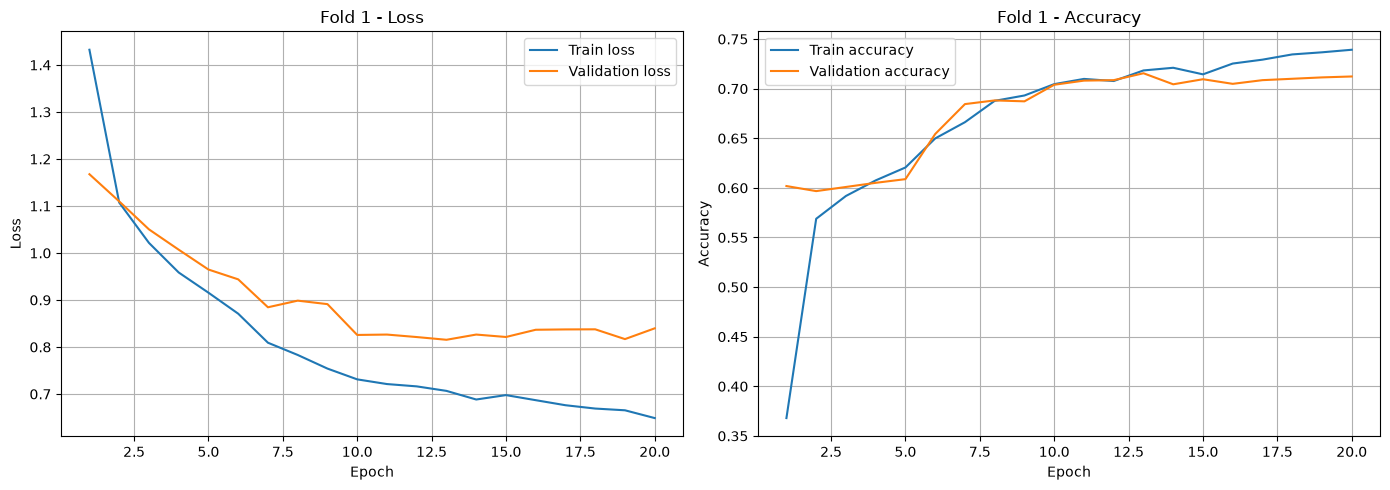

Fold 1: accuracy=0.5909, macro F1=0.2753

========== FOLD 2 ==========
Epoch 5/20 | train_loss=0.8172 | val_loss=0.9975 | train_acc=0.6552 | val_acc=0.6695
Epoch 10/20 | train_loss=0.7328 | val_loss=1.0370 | train_acc=0.6844 | val_acc=0.7147
Epoch 15/20 | train_loss=0.6901 | val_loss=1.0899 | train_acc=0.7082 | val_acc=0.7197
Epoch 20/20 | train_loss=0.6641 | val_loss=1.2314 | train_acc=0.7223 | val_acc=0.7161


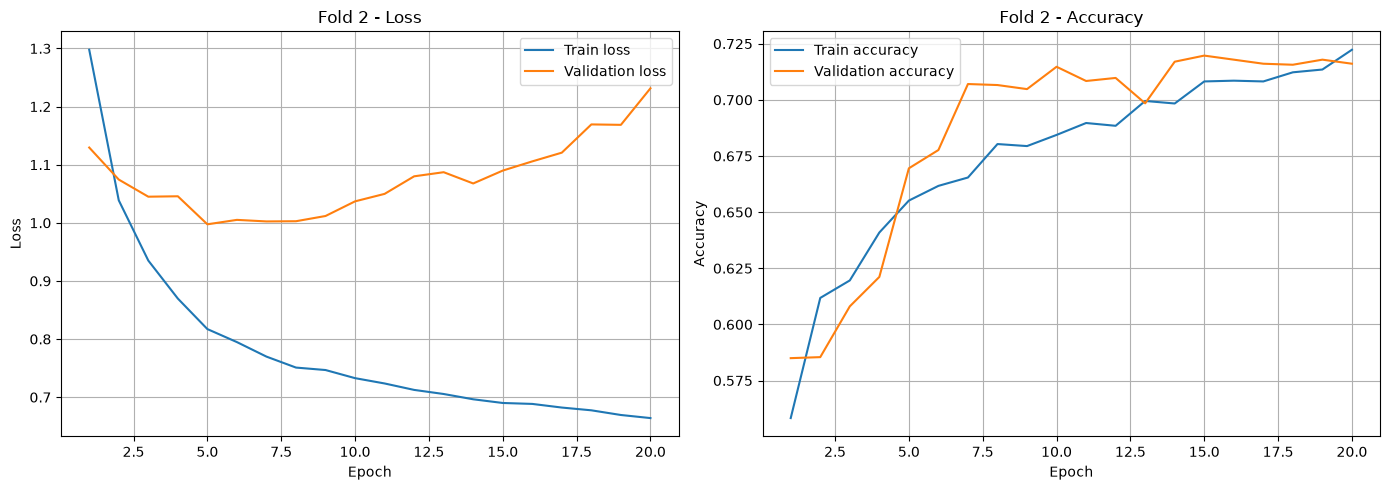

Fold 2: accuracy=0.7391, macro F1=0.6505

========== FOLD 3 ==========
Epoch 5/20 | train_loss=0.8868 | val_loss=1.0104 | train_acc=0.6563 | val_acc=0.6035
Epoch 10/20 | train_loss=0.7793 | val_loss=1.1155 | train_acc=0.6728 | val_acc=0.6172
Epoch 15/20 | train_loss=0.7148 | val_loss=1.6146 | train_acc=0.7044 | val_acc=0.6281
Epoch 20/20 | train_loss=0.6913 | val_loss=2.4971 | train_acc=0.7121 | val_acc=0.6630


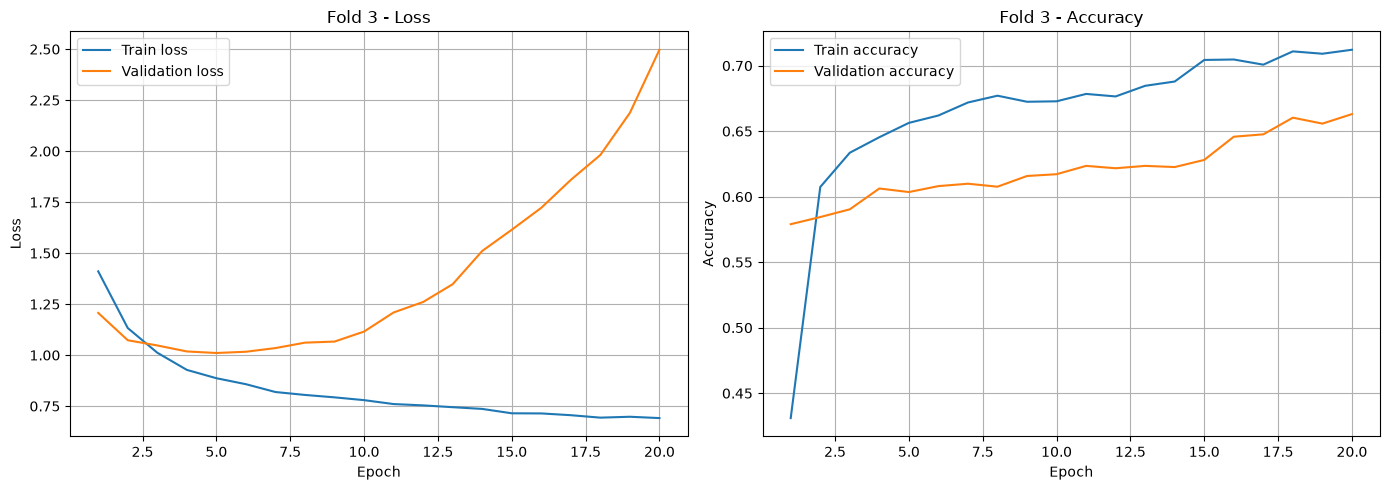

Fold 3: accuracy=0.6522, macro F1=0.3941

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.8990 | val_loss=1.6370 | train_acc=0.6601 | val_acc=0.5462
Epoch 10/20 | train_loss=0.7603 | val_loss=2.0518 | train_acc=0.7162 | val_acc=0.5488
Epoch 15/20 | train_loss=0.7021 | val_loss=2.2562 | train_acc=0.7316 | val_acc=0.5541
Epoch 20/20 | train_loss=0.6681 | val_loss=2.6407 | train_acc=0.7384 | val_acc=0.5658


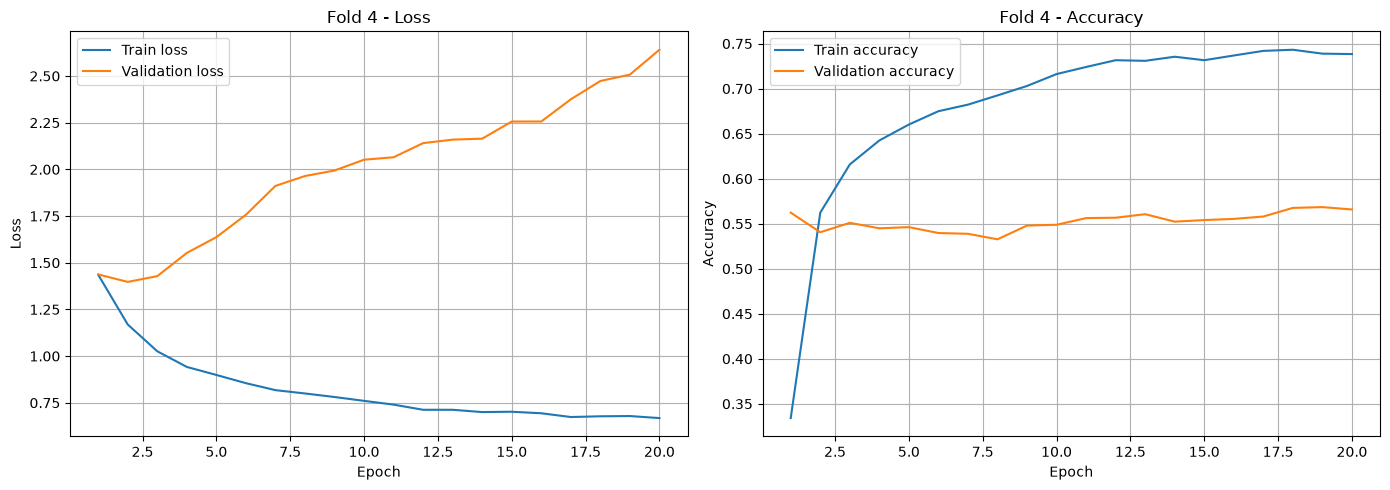

Fold 4: accuracy=0.6364, macro F1=0.3851

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.8239 | val_loss=0.8893 | train_acc=0.6702 | val_acc=0.6698
Epoch 10/20 | train_loss=0.7131 | val_loss=0.8487 | train_acc=0.7127 | val_acc=0.7156
Epoch 15/20 | train_loss=0.6704 | val_loss=0.8533 | train_acc=0.7317 | val_acc=0.7138
Epoch 20/20 | train_loss=0.6395 | val_loss=0.8972 | train_acc=0.7441 | val_acc=0.7224


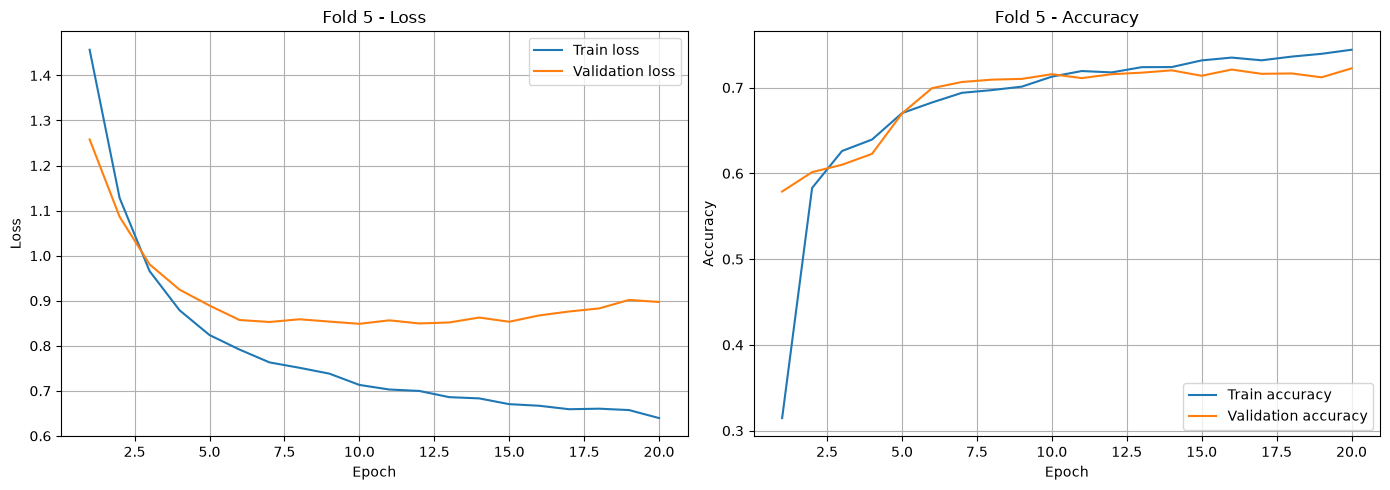

Fold 5: accuracy=0.6522, macro F1=0.5429

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6542
Mean macro F1: 0.4496


In [27]:
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001

fold_accuracies = []
fold_f1_scores = []

all_work_true = []
all_work_pred = []


for fold, (train_idx, test_idx) in enumerate(folds, start=1):

    print(f"\n========== FOLD {fold} ==========")

    # PODACI
    X_train = X[train_idx]
    y_train = y_encoded[train_idx]

    X_test = X[test_idx]
    y_test = y_encoded[test_idx]

    groups_test = groups[test_idx]


    # STANDARDIZACIJA
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # TRAIN DATASET + LOADER
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # MODEL
    model = SmallSegmentNeuralNetwork(
        input_size=X.shape[1],
        num_classes=len(label_encoder.classes_)
    ).to(device)


    # LOSS
    criterion = nn.CrossEntropyLoss()


    # OPTIMIZER
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # =====================================================
    # OVDJE POZIVAMO FUNKCIJU ZA TRENING
    # =====================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # GRAFICI
    plot_training_history(
        history,
        fold=fold
    )


    # TEST PREDIKCIJE
    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        pred = torch.argmax(logits, dim=1).cpu().numpy()


    # MAJORITY VOTE PO DJELU
    work_true, work_pred = majority_vote_prediction(
        y_test,
        pred,
        groups_test
    )


    # METRIKE
    accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    f1 = metrics.f1_score(
        work_true,
        work_pred,
        average="macro"
    )

    fold_accuracies.append(accuracy)
    fold_f1_scores.append(f1)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    print(
        f"Fold {fold}: "
        f"accuracy={accuracy:.4f}, "
        f"macro F1={f1:.4f}"
    )


print("\n========== UKUPNI REZULTATI ==========")

print(
    f"Mean accuracy: {np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean macro F1: {np.mean(fold_f1_scores):.4f}"
)

<span style="font-size:20px">
Naime, nijedan od navedenih pristupa nije urodio plodom, u svakom slucaju se neuronska mreza preprilagodjavala. Mozemo pokusati sada klasifikaciju gdje akumuliramo feature vektore svih segmenata u jedan feature vektor koji ce da koristi cijela kompozicija
</span>

In [28]:
import numpy as np

def make_work_level_dataset(X, y, groups):

    X_work = []
    y_work = []
    work_ids = []

    for work_id in np.unique(groups):

        mask = groups == work_id

        X_segments = X[mask]
        y_segments = y[mask]

        mean_features = X_segments.mean(axis=0)
        std_features = X_segments.std(axis=0)

        work_features = np.concatenate([
            mean_features,
            std_features
        ])

        X_work.append(work_features)
        y_work.append(y_segments[0])
        work_ids.append(work_id)

    X_work = np.array(X_work)
    y_work = np.array(y_work)
    work_ids = np.array(work_ids)

    return X_work, y_work, work_ids

In [29]:
X_work, y_work, work_ids = make_work_level_dataset(X,y,groups)

In [30]:
class WorkNN_Small(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']
Class counts: (array([0, 1, 2, 3, 4]), array([30, 55,  8, 11,  9]))

========== FOLD 1 ==========
Epoch 5/30 | train_loss=1.3260 | val_loss=1.2049 | train_acc=0.5333 | val_acc=0.7826
Epoch 10/30 | train_loss=0.9699 | val_loss=0.9106 | train_acc=0.7667 | val_acc=0.7826
Epoch 15/30 | train_loss=0.7507 | val_loss=0.7772 | train_acc=0.8000 | val_acc=0.7826
Epoch 20/30 | train_loss=0.7277 | val_loss=0.7394 | train_acc=0.7889 | val_acc=0.7826
Epoch 25/30 | train_loss=0.6268 | val_loss=0.7099 | train_acc=0.7889 | val_acc=0.7826
Epoch 30/30 | train_loss=0.5753 | val_loss=0.6848 | train_acc=0.8111 | val_acc=0.7826


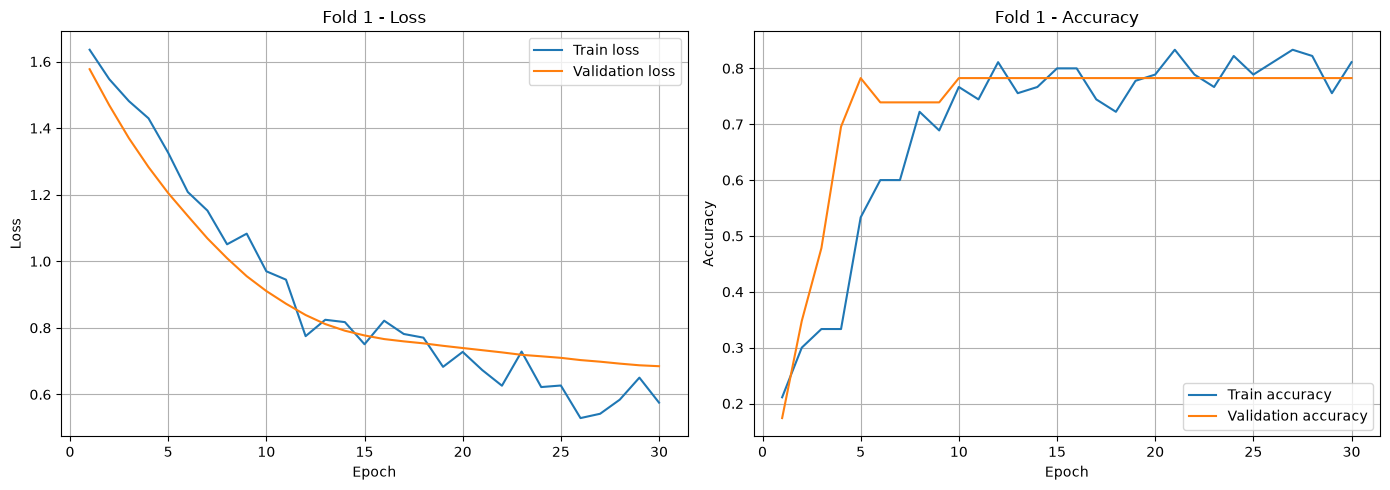


Fold 1 results:
Accuracy: 0.7826
Macro F1: 0.4808
Final train loss: 0.5753
Final validation loss: 0.6848

========== FOLD 2 ==========
Epoch 5/30 | train_loss=1.3590 | val_loss=1.3190 | train_acc=0.5000 | val_acc=0.5217
Epoch 10/30 | train_loss=1.0183 | val_loss=1.1526 | train_acc=0.7333 | val_acc=0.6522
Epoch 15/30 | train_loss=0.8858 | val_loss=1.0638 | train_acc=0.7333 | val_acc=0.6522
Epoch 20/30 | train_loss=0.7345 | val_loss=1.0064 | train_acc=0.7778 | val_acc=0.6522
Epoch 25/30 | train_loss=0.6430 | val_loss=0.9585 | train_acc=0.8444 | val_acc=0.6087
Epoch 30/30 | train_loss=0.5953 | val_loss=0.9319 | train_acc=0.8444 | val_acc=0.6087


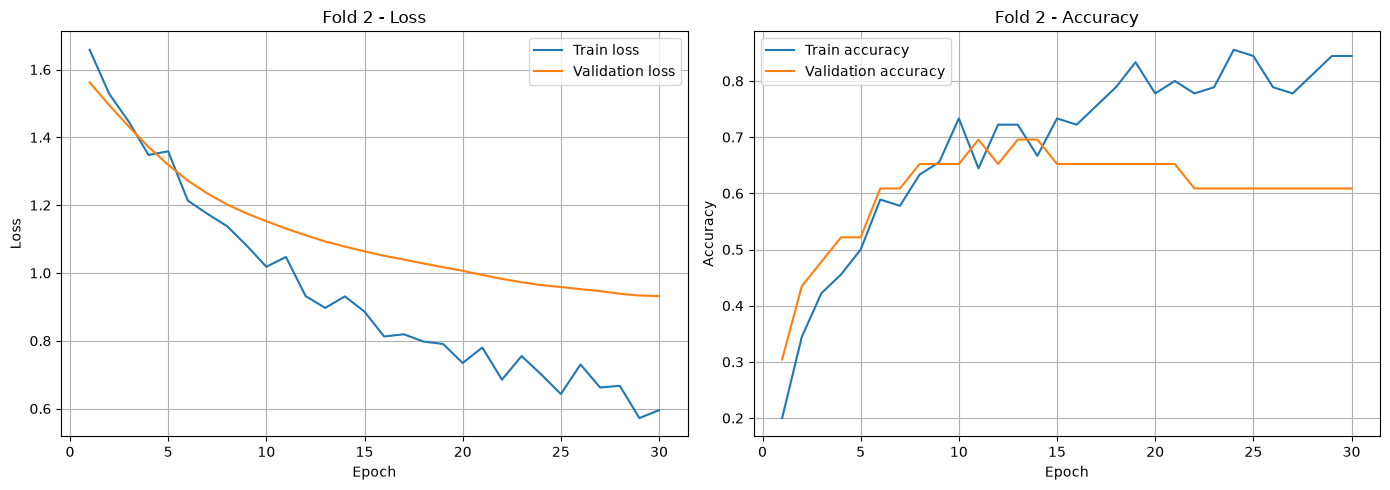


Fold 2 results:
Accuracy: 0.6087
Macro F1: 0.3714
Final train loss: 0.5953
Final validation loss: 0.9319

========== FOLD 3 ==========
Epoch 5/30 | train_loss=1.3304 | val_loss=1.2578 | train_acc=0.4778 | val_acc=0.6957
Epoch 10/30 | train_loss=1.0150 | val_loss=1.0015 | train_acc=0.7667 | val_acc=0.7826
Epoch 15/30 | train_loss=0.7970 | val_loss=0.8378 | train_acc=0.7444 | val_acc=0.7826
Epoch 20/30 | train_loss=0.7012 | val_loss=0.7417 | train_acc=0.7222 | val_acc=0.7826
Epoch 25/30 | train_loss=0.5519 | val_loss=0.6852 | train_acc=0.8444 | val_acc=0.7826
Epoch 30/30 | train_loss=0.5802 | val_loss=0.6493 | train_acc=0.8111 | val_acc=0.7826


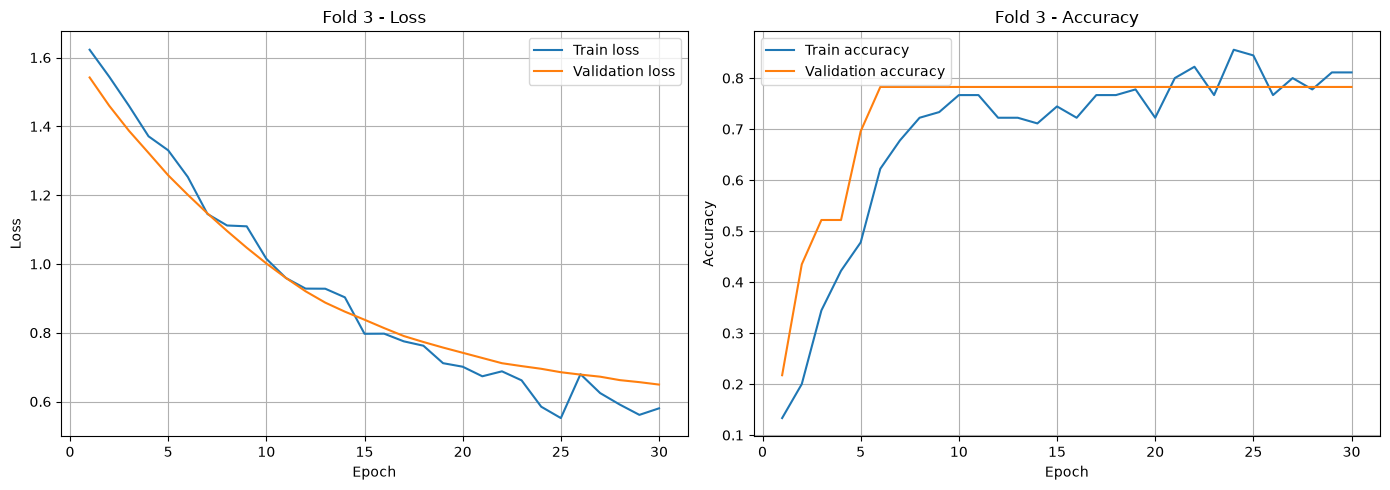


Fold 3 results:
Accuracy: 0.7826
Macro F1: 0.4872
Final train loss: 0.5802
Final validation loss: 0.6493

========== FOLD 4 ==========
Epoch 5/30 | train_loss=1.2263 | val_loss=1.2887 | train_acc=0.5165 | val_acc=0.4091
Epoch 10/30 | train_loss=0.9953 | val_loss=1.0492 | train_acc=0.6593 | val_acc=0.5909
Epoch 15/30 | train_loss=0.8380 | val_loss=0.9080 | train_acc=0.7033 | val_acc=0.6818
Epoch 20/30 | train_loss=0.6887 | val_loss=0.8324 | train_acc=0.7802 | val_acc=0.7273
Epoch 25/30 | train_loss=0.5709 | val_loss=0.7782 | train_acc=0.7912 | val_acc=0.7273
Epoch 30/30 | train_loss=0.5122 | val_loss=0.7505 | train_acc=0.8462 | val_acc=0.7273


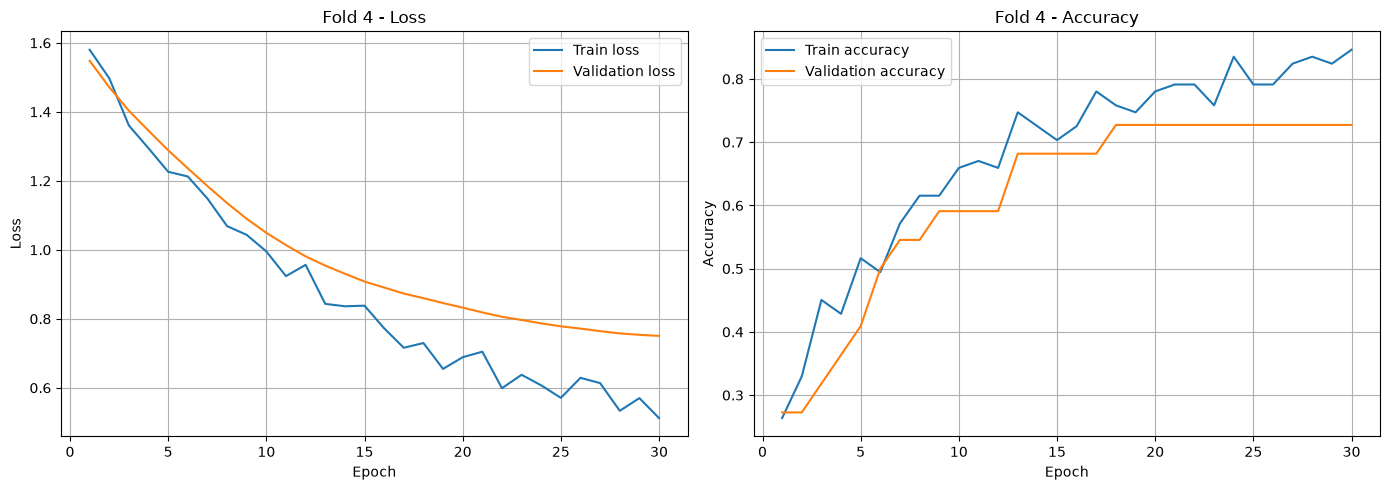


Fold 4 results:
Accuracy: 0.7273
Macro F1: 0.4146
Final train loss: 0.5122
Final validation loss: 0.7505

========== FOLD 5 ==========
Epoch 5/30 | train_loss=1.2860 | val_loss=1.2090 | train_acc=0.6044 | val_acc=0.7273
Epoch 10/30 | train_loss=0.9799 | val_loss=0.9589 | train_acc=0.7692 | val_acc=0.6818
Epoch 15/30 | train_loss=0.8479 | val_loss=0.7769 | train_acc=0.7363 | val_acc=0.7727
Epoch 20/30 | train_loss=0.6795 | val_loss=0.6660 | train_acc=0.8242 | val_acc=0.7727
Epoch 25/30 | train_loss=0.6202 | val_loss=0.6038 | train_acc=0.7912 | val_acc=0.7727
Epoch 30/30 | train_loss=0.5880 | val_loss=0.5672 | train_acc=0.7802 | val_acc=0.7727


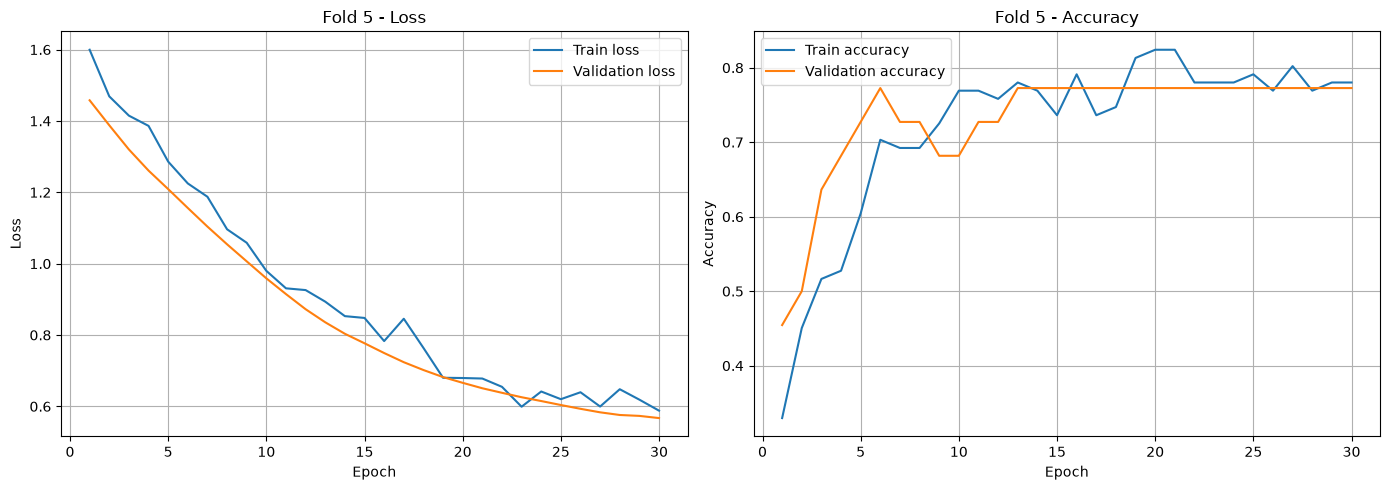


Fold 5 results:
Accuracy: 0.7727
Macro F1: 0.3538
Final train loss: 0.5880
Final validation loss: 0.5672

========== GENERAL RESULTS ==========
Mean Accuracy: 0.7348
Mean Macro F1: 0.4216

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

        Bach       0.81      1.00      0.90        30
   Beethoven       0.73      0.89      0.80        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.50      0.36      0.42        11
    Schubert       0.00      0.00      0.00         9

    accuracy                           0.73       113
   macro avg       0.41      0.45      0.42       113
weighted avg       0.62      0.73      0.67       113



In [31]:
import numpy as np
import torch
import torch.nn as nn

from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold

from torch.utils.data import TensorDataset, DataLoader

from evaluation import (
    train_and_evaluate_neural_network,
    plot_training_history
)


# ============================================================
# CUDA
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder_work = LabelEncoder()

y_work_encoded = label_encoder_work.fit_transform(
    y_work
)

print("Classes:", label_encoder_work.classes_)

print(
    "Class counts:",
    np.unique(
        y_work_encoded,
        return_counts=True
    )
)


# ============================================================
# FOLDOVI
# Jedan red = jedno djelo, tako da nam groups vise ne treba
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

work_folds = list(
    skf.split(
        X_work,
        y_work_encoded
    )
)


# ============================================================
# PARAMETRI
# ============================================================

EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 0.001


# ============================================================
# IZABERI MREZU
# ============================================================

# Promijeni samo ovu liniju kada hoces drugu arhitekturu:
MODEL_CLASS = WorkNN_Small

# npr:
# MODEL_CLASS = WorkNN_Medium
# MODEL_CLASS = WorkNN_Large


# ============================================================
# REZULTATI
# ============================================================

fold_accuracies = []
fold_f1_scores = []

all_true = []
all_pred = []


# ============================================================
# 5-FOLD CROSS VALIDATION
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    work_folds,
    start=1
):

    print(f"\n========== FOLD {fold} ==========")


    # --------------------------------------------------------
    # TRAIN / TEST
    # --------------------------------------------------------

    X_train = X_work[train_idx]
    y_train = y_work_encoded[train_idx]

    X_test = X_work[test_idx]
    y_test = y_work_encoded[test_idx]


    # --------------------------------------------------------
    # STANDARDIZACIJA
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # --------------------------------------------------------
    # TENSORI ZA TRAIN
    # --------------------------------------------------------

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )


    # --------------------------------------------------------
    # DATASET + DATALOADER
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # --------------------------------------------------------
    # NOV MODEL ZA SVAKI FOLD
    # --------------------------------------------------------

    model = MODEL_CLASS(
        input_size=X_work.shape[1],
        num_classes=len(
            label_encoder_work.classes_
        )
    ).to(device)


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # ========================================================
    # TRENING + EVALUACIJA
    # ========================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # ========================================================
    # PLOT ZA OVAJ FOLD
    # ========================================================

    plot_training_history(
        history,
        fold=fold
    )


    # ========================================================
    # FINALNE PREDIKCIJE OVOG FOLDA
    # ========================================================

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        logits = model(
            X_test_tensor
        )

        predictions = torch.argmax(
            logits,
            dim=1
        ).cpu().numpy()


    # ========================================================
    # METRIKE
    # ========================================================

    accuracy = metrics.accuracy_score(
        y_test,
        predictions
    )

    f1 = metrics.f1_score(
        y_test,
        predictions,
        average="macro"
    )


    fold_accuracies.append(
        accuracy
    )

    fold_f1_scores.append(
        f1
    )

    all_true.extend(
        y_test
    )

    all_pred.extend(
        predictions
    )


    print(
        f"\nFold {fold} results:"
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Macro F1: {f1:.4f}"
    )

    print(
        f"Final train loss: "
        f"{history['train_loss'][-1]:.4f}"
    )

    print(
        f"Final validation loss: "
        f"{history['val_loss'][-1]:.4f}"
    )


# ============================================================
# UKUPNI REZULTATI
# ============================================================

print(
    "\n========== GENERAL RESULTS =========="
)

print(
    f"Mean Accuracy: "
    f"{np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean Macro F1: "
    f"{np.mean(fold_f1_scores):.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    "\n========== CLASSIFICATION REPORT =========="
)

print(
    metrics.classification_report(
        all_true,
        all_pred,
        labels=range(
            len(label_encoder_work.classes_)
        ),
        target_names=
            label_encoder_work.classes_,
        zero_division=0
    )
)

In [32]:
# Vidimo da smo uspjeli da poboljsamo rezultate po pitanju preprilagodjavanja

In [33]:
class WorkNN_Compact(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']
Class counts: (array([0, 1, 2, 3, 4]), array([30, 55,  8, 11,  9]))

========== FOLD 1 ==========
Epoch 5/60 | train_loss=1.3622 | val_loss=1.2992 | train_acc=0.5333 | val_acc=0.6957
Epoch 10/60 | train_loss=1.1680 | val_loss=1.0331 | train_acc=0.5667 | val_acc=0.6957
Epoch 15/60 | train_loss=0.9423 | val_loss=0.9032 | train_acc=0.6556 | val_acc=0.7391


Epoch 20/60 | train_loss=0.9056 | val_loss=0.8416 | train_acc=0.6556 | val_acc=0.7391
Epoch 25/60 | train_loss=0.8963 | val_loss=0.8049 | train_acc=0.6444 | val_acc=0.7391
Epoch 30/60 | train_loss=0.8342 | val_loss=0.7916 | train_acc=0.6333 | val_acc=0.7391
Epoch 35/60 | train_loss=0.8618 | val_loss=0.7888 | train_acc=0.6222 | val_acc=0.7391
Epoch 40/60 | train_loss=0.7415 | val_loss=0.7872 | train_acc=0.6556 | val_acc=0.7391
Epoch 45/60 | train_loss=0.7477 | val_loss=0.7804 | train_acc=0.6778 | val_acc=0.7391
Epoch 50/60 | train_loss=0.7093 | val_loss=0.7719 | train_acc=0.6556 | val_acc=0.7391
Epoch 55/60 | train_loss=0.6974 | val_loss=0.7677 | train_acc=0.7000 | val_acc=0.7391
Epoch 60/60 | train_loss=0.6305 | val_loss=0.7684 | train_acc=0.6889 | val_acc=0.7391


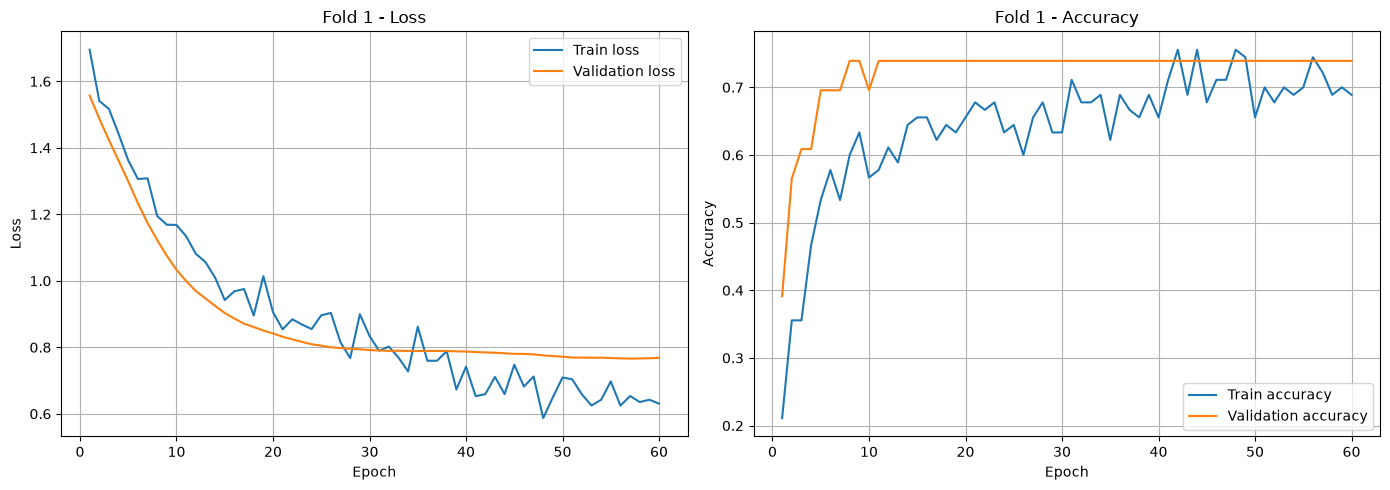


---------- FOLD 1 RESULTS ----------
Accuracy: 0.7391
Macro F1: 0.3407
Final train loss: 0.6305
Final validation loss: 0.7684

========== FOLD 2 ==========
Epoch 5/60 | train_loss=1.2989 | val_loss=1.3797 | train_acc=0.5333 | val_acc=0.5652
Epoch 10/60 | train_loss=1.0595 | val_loss=1.2011 | train_acc=0.6667 | val_acc=0.6087
Epoch 15/60 | train_loss=0.8668 | val_loss=1.0893 | train_acc=0.7444 | val_acc=0.6522
Epoch 20/60 | train_loss=0.9301 | val_loss=1.0319 | train_acc=0.7222 | val_acc=0.6522
Epoch 25/60 | train_loss=0.7341 | val_loss=1.0245 | train_acc=0.7444 | val_acc=0.6522
Epoch 30/60 | train_loss=0.6514 | val_loss=1.0110 | train_acc=0.7556 | val_acc=0.6087
Epoch 35/60 | train_loss=0.7904 | val_loss=0.9977 | train_acc=0.7111 | val_acc=0.6087
Epoch 40/60 | train_loss=0.6843 | val_loss=0.9859 | train_acc=0.7556 | val_acc=0.6087
Epoch 45/60 | train_loss=0.7170 | val_loss=0.9733 | train_acc=0.7778 | val_acc=0.6087
Epoch 50/60 | train_loss=0.6194 | val_loss=0.9703 | train_acc=0.7778 |

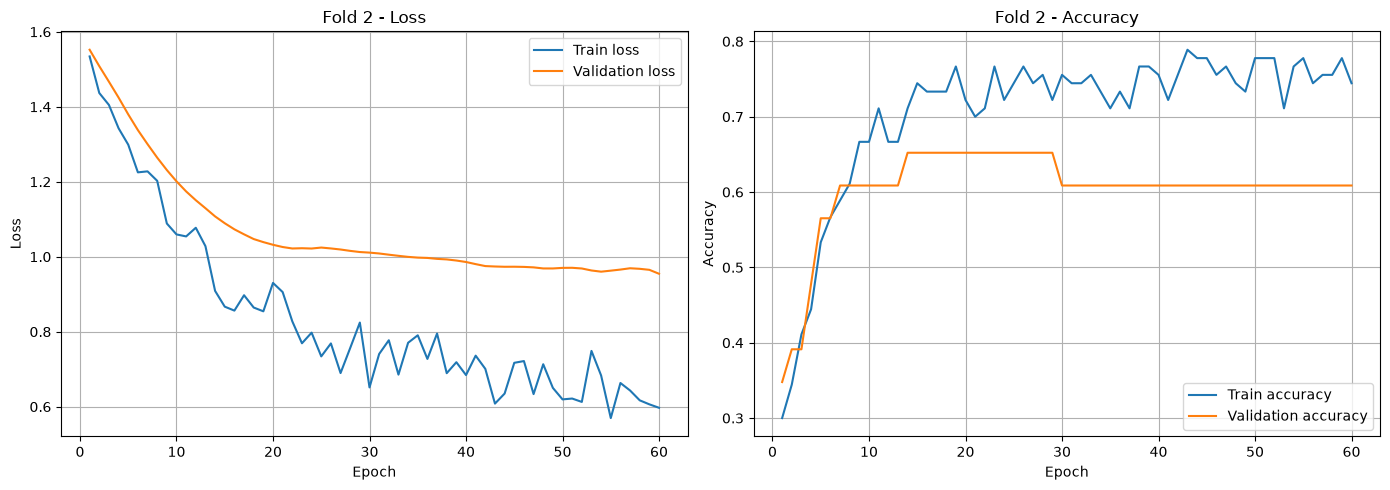


---------- FOLD 2 RESULTS ----------
Accuracy: 0.6087
Macro F1: 0.3629
Final train loss: 0.5971
Final validation loss: 0.9546

========== FOLD 3 ==========
Epoch 5/60 | train_loss=1.2975 | val_loss=1.2826 | train_acc=0.5889 | val_acc=0.6957
Epoch 10/60 | train_loss=1.1052 | val_loss=1.0811 | train_acc=0.6778 | val_acc=0.7391
Epoch 15/60 | train_loss=1.0056 | val_loss=0.9852 | train_acc=0.6333 | val_acc=0.7391
Epoch 20/60 | train_loss=0.8719 | val_loss=0.9196 | train_acc=0.7222 | val_acc=0.7391
Epoch 25/60 | train_loss=0.8707 | val_loss=0.8764 | train_acc=0.6889 | val_acc=0.7391
Epoch 30/60 | train_loss=0.8164 | val_loss=0.8557 | train_acc=0.6556 | val_acc=0.7391
Epoch 35/60 | train_loss=0.8713 | val_loss=0.8242 | train_acc=0.6667 | val_acc=0.7391
Epoch 40/60 | train_loss=0.7749 | val_loss=0.7882 | train_acc=0.6667 | val_acc=0.7391
Epoch 45/60 | train_loss=0.7954 | val_loss=0.7648 | train_acc=0.7000 | val_acc=0.7391
Epoch 50/60 | train_loss=0.7345 | val_loss=0.7422 | train_acc=0.7000 |

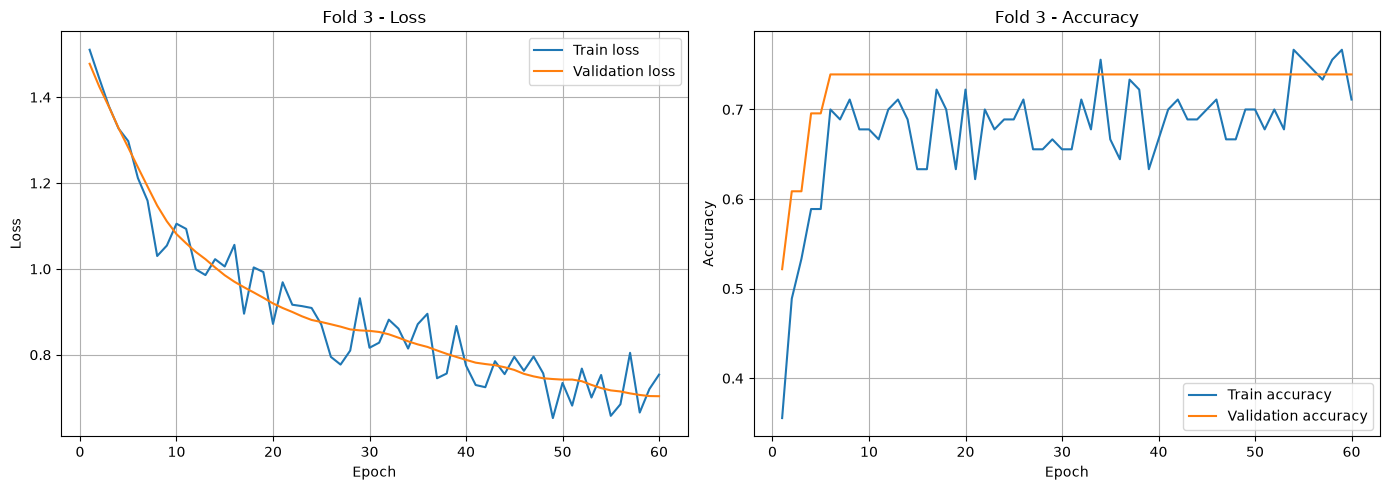


---------- FOLD 3 RESULTS ----------
Accuracy: 0.7391
Macro F1: 0.3571
Final train loss: 0.7538
Final validation loss: 0.7035

========== FOLD 4 ==========
Epoch 5/60 | train_loss=1.3288 | val_loss=1.3583 | train_acc=0.6154 | val_acc=0.5000
Epoch 10/60 | train_loss=1.1646 | val_loss=1.1929 | train_acc=0.6593 | val_acc=0.6364
Epoch 15/60 | train_loss=1.0364 | val_loss=1.0135 | train_acc=0.7033 | val_acc=0.6364
Epoch 20/60 | train_loss=0.9454 | val_loss=0.8896 | train_acc=0.6703 | val_acc=0.6364
Epoch 25/60 | train_loss=0.8363 | val_loss=0.8178 | train_acc=0.6703 | val_acc=0.6364
Epoch 30/60 | train_loss=0.7928 | val_loss=0.7788 | train_acc=0.7363 | val_acc=0.6818
Epoch 35/60 | train_loss=0.7017 | val_loss=0.7534 | train_acc=0.7582 | val_acc=0.6818
Epoch 40/60 | train_loss=0.7318 | val_loss=0.7410 | train_acc=0.6703 | val_acc=0.6818
Epoch 45/60 | train_loss=0.7857 | val_loss=0.7241 | train_acc=0.6703 | val_acc=0.6818
Epoch 50/60 | train_loss=0.6547 | val_loss=0.7255 | train_acc=0.7692 |

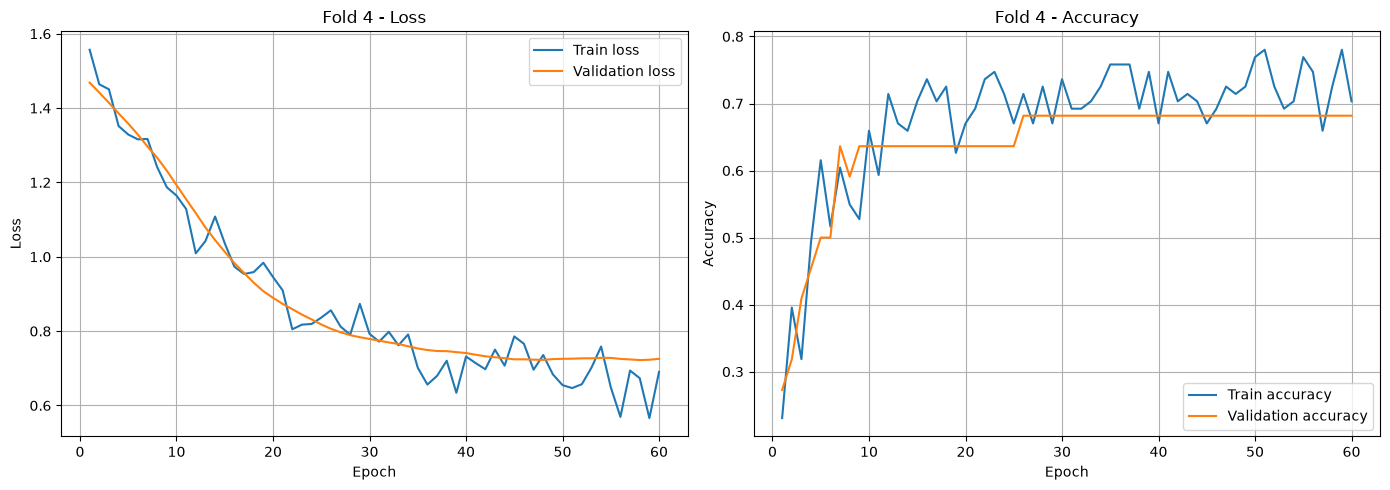


---------- FOLD 4 RESULTS ----------
Accuracy: 0.6818
Macro F1: 0.3154
Final train loss: 0.6903
Final validation loss: 0.7255

========== FOLD 5 ==========
Epoch 5/60 | train_loss=1.4590 | val_loss=1.3824 | train_acc=0.3626 | val_acc=0.4545
Epoch 10/60 | train_loss=1.3031 | val_loss=1.1885 | train_acc=0.4615 | val_acc=0.6818
Epoch 15/60 | train_loss=1.0868 | val_loss=1.0407 | train_acc=0.5604 | val_acc=0.7273
Epoch 20/60 | train_loss=1.1036 | val_loss=0.9296 | train_acc=0.5714 | val_acc=0.7273
Epoch 25/60 | train_loss=0.9223 | val_loss=0.8551 | train_acc=0.6374 | val_acc=0.7727
Epoch 30/60 | train_loss=0.8387 | val_loss=0.7968 | train_acc=0.6703 | val_acc=0.8182
Epoch 35/60 | train_loss=0.9395 | val_loss=0.7493 | train_acc=0.6374 | val_acc=0.7727
Epoch 40/60 | train_loss=0.8589 | val_loss=0.7103 | train_acc=0.7033 | val_acc=0.8182
Epoch 45/60 | train_loss=0.8310 | val_loss=0.6809 | train_acc=0.7033 | val_acc=0.7727
Epoch 50/60 | train_loss=0.7751 | val_loss=0.6477 | train_acc=0.7692 |

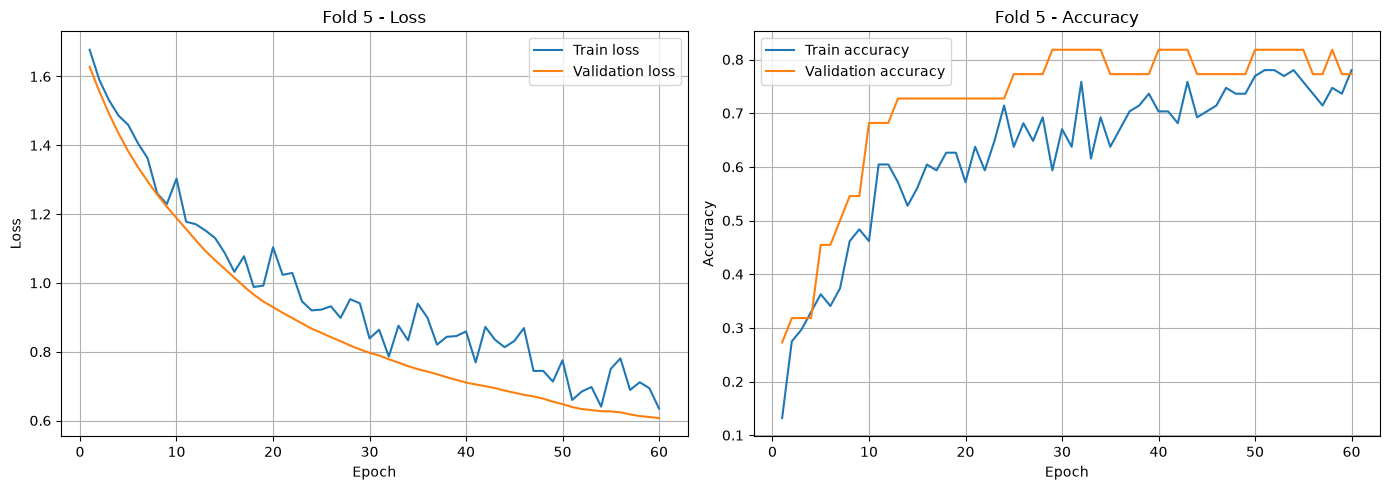


---------- FOLD 5 RESULTS ----------
Accuracy: 0.7727
Macro F1: 0.4919
Final train loss: 0.6347
Final validation loss: 0.6070

========== GENERAL RESULTS ==========
Mean Accuracy: 0.7083
Mean Macro F1: 0.3736

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

        Bach       0.83      0.97      0.89        30
   Beethoven       0.70      0.89      0.78        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.33      0.18      0.24        11
    Schubert       0.00      0.00      0.00         9

    accuracy                           0.71       113
   macro avg       0.37      0.41      0.38       113
weighted avg       0.59      0.71      0.64       113



In [34]:
import numpy as np
import torch
import torch.nn as nn

from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold

from torch.utils.data import TensorDataset, DataLoader

from evaluation import (
    train_and_evaluate_neural_network,
    plot_training_history
)


# ============================================================
# ARHITEKTURA
# ============================================================

class WorkNN_Compact(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# ============================================================
# CUDA
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder_work = LabelEncoder()

y_work_encoded = label_encoder_work.fit_transform(
    y_work
)

print("Classes:", label_encoder_work.classes_)

print(
    "Class counts:",
    np.unique(
        y_work_encoded,
        return_counts=True
    )
)


# ============================================================
# FOLDOVI
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

work_folds = list(
    skf.split(
        X_work,
        y_work_encoded
    )
)


# ============================================================
# PARAMETRI
# ============================================================

EPOCHS = 60
BATCH_SIZE = 16
LEARNING_RATE = 0.001


# ============================================================
# REZULTATI
# ============================================================

fold_accuracies = []
fold_f1_scores = []

all_true = []
all_pred = []


# ============================================================
# 5-FOLD CROSS VALIDATION
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    work_folds,
    start=1
):

    print(f"\n========== FOLD {fold} ==========")


    # ========================================================
    # TRAIN / TEST
    # ========================================================

    X_train = X_work[train_idx]
    y_train = y_work_encoded[train_idx]

    X_test = X_work[test_idx]
    y_test = y_work_encoded[test_idx]


    # ========================================================
    # STANDARDIZACIJA
    # ========================================================

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # ========================================================
    # TENSORI
    # ========================================================

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )


    # ========================================================
    # DATALOADER
    # ========================================================

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # ========================================================
    # NOVA MREZA ZA SVAKI FOLD
    # ========================================================

    model = WorkNN_Compact(
        input_size=X_work.shape[1],
        num_classes=len(
            label_encoder_work.classes_
        )
    ).to(device)


    # ========================================================
    # LOSS
    # ========================================================

    criterion = nn.CrossEntropyLoss()


    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )


    # ========================================================
    # TRENING + EVALUACIJA
    # ========================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # ========================================================
    # GRAFICI
    # ========================================================

    plot_training_history(
        history,
        fold=fold
    )


    # ========================================================
    # FINALNE PREDIKCIJE
    # ========================================================

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)


    model.eval()

    with torch.no_grad():

        logits = model(
            X_test_tensor
        )

        predictions = torch.argmax(
            logits,
            dim=1
        ).cpu().numpy()


    # ========================================================
    # METRIKE
    # ========================================================

    accuracy = metrics.accuracy_score(
        y_test,
        predictions
    )

    f1 = metrics.f1_score(
        y_test,
        predictions,
        average="macro"
    )


    fold_accuracies.append(
        accuracy
    )

    fold_f1_scores.append(
        f1
    )

    all_true.extend(
        y_test
    )

    all_pred.extend(
        predictions
    )


    # ========================================================
    # ISPIS FOLDA
    # ========================================================

    print(
        f"\n---------- FOLD {fold} RESULTS ----------"
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Macro F1: {f1:.4f}"
    )

    print(
        f"Final train loss: "
        f"{history['train_loss'][-1]:.4f}"
    )

    print(
        f"Final validation loss: "
        f"{history['val_loss'][-1]:.4f}"
    )


# ============================================================
# GENERAL RESULTS
# ============================================================

print(
    "\n========== GENERAL RESULTS =========="
)

print(
    f"Mean Accuracy: "
    f"{np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean Macro F1: "
    f"{np.mean(fold_f1_scores):.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    "\n========== CLASSIFICATION REPORT =========="
)

print(
    metrics.classification_report(
        all_true,
        all_pred,
        labels=range(
            len(label_encoder_work.classes_)
        ),
        target_names=
            label_encoder_work.classes_,
        zero_division=0
    )
)

<span style="font-size:20px">
Dakle, uspjeli smo da se mreza ne preprilagodi toliko podacima, ali smo morali da uzmemo jako malu mrezu sto nam je umanjilo prediktivne sposobnosti znacajno u ovako teskom problemu klasifikacije
</span>